# 1D Heat Equation PINN Setup

This notebook begins the implementation of a Physics-Informed Neural Network (PINN) for the one-dimensional heat equation. We will define the problem, implement the model, build the physics-based loss, generate training points, train the network, and visualize the result.

The goal is to bridge the analytical solution to the PINN implementation in a clear, reproducible workflow.


## Section 1: Import Required Libraries

Import PyTorch, NumPy, plotting utilities, and helper functions needed to build and visualize the PINN.


In [3]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

# Set a reproducible seed for the notebook
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib for notebook display
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 12,
    }
)

## Section 2: Define Problem Domain and Parameters

We solve the 1D heat equation

\[
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2},
\]

for \((x, t) \in [0, 1] \times [0, 1]\) with initial condition \((u(x,0) = \sin(\pi x))\) and homogeneous Dirichlet boundary conditions \((u(0,t) = u(1,t) = 0)\).

The parameter \((\alpha)\) is the thermal diffusivity.


In [4]:
# Problem domain and PDE parameters
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0
alpha = 1.0

# Training point counts
n_interior = 5000
n_boundary = 200
n_initial = 200

# Evaluation grid for visualization
n_x = 201
n_t = 201

## Section 3: Build the PINN Model

We define a fully connected neural network that accepts \((x, t)\) and predicts the temperature \((u(x,t))\). The model should be expressive enough to capture the smooth solution of the heat equation while remaining small enough for efficient training.


In [5]:
class PINN(nn.Module):
    def __init__(self, input_dim: int = 2, hidden_dim: int = 64, num_layers: int = 4):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        xt = torch.cat([x, t], dim=-1)
        return self.network(xt)


model = PINN(hidden_dim=64, num_layers=4)
model

PINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

## Section 4: Define PDE Residual and Loss Functions

The PINN loss combines three terms:

1. PDE residual loss on interior collocation points.
2. Initial condition loss at \((t = 0)\).
3. Boundary condition loss at \((x = 0)\) and \((x = 1)\).

The residual for the heat equation is

\[
R(x,t) = u_t(x,t) - \alpha u_{xx}(x,t).
\]


In [6]:
def pde_residual(
    model: nn.Module, x: torch.Tensor, t: torch.Tensor, alpha: float
) -> torch.Tensor:
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    u = model(x, t)
    u_t = torch.autograd.grad(
        u, t, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True
    )[0]
    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0]

    return u_t - alpha * u_xx


def pinn_loss(
    model: nn.Module,
    interior_x: torch.Tensor,
    interior_t: torch.Tensor,
    initial_x: torch.Tensor,
    initial_t: torch.Tensor,
    boundary_x: torch.Tensor,
    boundary_t: torch.Tensor,
    alpha: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    residual = pde_residual(model, interior_x, interior_t, alpha)
    pde_loss = torch.mean(residual**2)

    u_initial_pred = model(initial_x, initial_t)
    u_initial_true = torch.sin(math.pi * initial_x)
    initial_loss = torch.mean((u_initial_pred - u_initial_true) ** 2)

    u_boundary_pred = model(boundary_x, boundary_t)
    boundary_loss = torch.mean(u_boundary_pred**2)

    total_loss = pde_loss + initial_loss + boundary_loss
    return total_loss, pde_loss, initial_loss, boundary_loss

## Section 5: Set Up Training Data and Boundary Conditions

We generate interior collocation points across the space-time domain and explicit points for the initial and boundary conditions.

The generator here uses random sampling to spread the training points across the domain.


In [7]:
def sample_interior_points(n_points: int) -> tuple[torch.Tensor, torch.Tensor]:
    x = torch.rand((n_points, 1), dtype=torch.float32) * (x_max - x_min) + x_min
    t = torch.rand((n_points, 1), dtype=torch.float32) * (t_max - t_min) + t_min
    return x, t


def sample_initial_points(n_points: int) -> tuple[torch.Tensor, torch.Tensor]:
    x = torch.rand((n_points, 1), dtype=torch.float32) * (x_max - x_min) + x_min
    t = torch.zeros_like(x)
    return x, t


def sample_boundary_points(n_points: int) -> tuple[torch.Tensor, torch.Tensor]:
    n_half = n_points // 2
    t_left = torch.rand((n_half, 1), dtype=torch.float32) * (t_max - t_min) + t_min
    t_right = (
        torch.rand((n_points - n_half, 1), dtype=torch.float32) * (t_max - t_min)
        + t_min
    )
    x_left = torch.zeros_like(t_left)
    x_right = torch.ones_like(t_right)
    x = torch.cat([x_left, x_right], dim=0)
    t = torch.cat([t_left, t_right], dim=0)
    return x, t


interior_x, interior_t = sample_interior_points(n_interior)
initial_x, initial_t = sample_initial_points(n_initial)
boundary_x, boundary_t = sample_boundary_points(n_boundary)

interior_x.shape, interior_t.shape, initial_x.shape, boundary_x.shape

(torch.Size([5000, 1]),
 torch.Size([5000, 1]),
 torch.Size([200, 1]),
 torch.Size([200, 1]))

## Section 6: Train the Neural Network

We optimize the PINN using Adam and monitor all loss components. Training will focus on the PDE residual and enforcement of the initial/boundary conditions.


In [1]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 2000

loss_history = {
    "total": [],
    "pde": [],
    "initial": [],
    "boundary": [],
}

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    total_loss, pde_loss, initial_loss, boundary_loss = pinn_loss(
        model,
        interior_x,
        interior_t,
        initial_x,
        initial_t,
        boundary_x,
        boundary_t,
        alpha,
    )
    total_loss.backward()
    optimizer.step()

    loss_history["total"].append(total_loss.item())
    loss_history["pde"].append(pde_loss.item())
    loss_history["initial"].append(initial_loss.item())
    loss_history["boundary"].append(boundary_loss.item())

    if epoch % 250 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:04d} | \
            total={total_loss.item():.4e} | pde={pde_loss.item():.4e} | \
                initial={initial_loss.item():.4e} | \
                    boundary={boundary_loss.item():.4e}"
        )

plt.figure()
plt.semilogy(loss_history["total"], label="Total Loss")
plt.semilogy(loss_history["pde"], label="PDE Loss")
plt.semilogy(loss_history["initial"], label="Initial Loss")
plt.semilogy(loss_history["boundary"], label="Boundary Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("PINN Loss Convergence")
plt.grid(True)
plt.show()

NameError: name 'torch' is not defined

## Section 7: Evaluate and Visualize Results

We evaluate the trained PINN on a dense grid and compare the predicted temperature field to the analytical solution from the heat equation.


Max absolute error on evaluation grid: 3.1576e-02
Mean absolute error on evaluation grid: 6.7532e-03


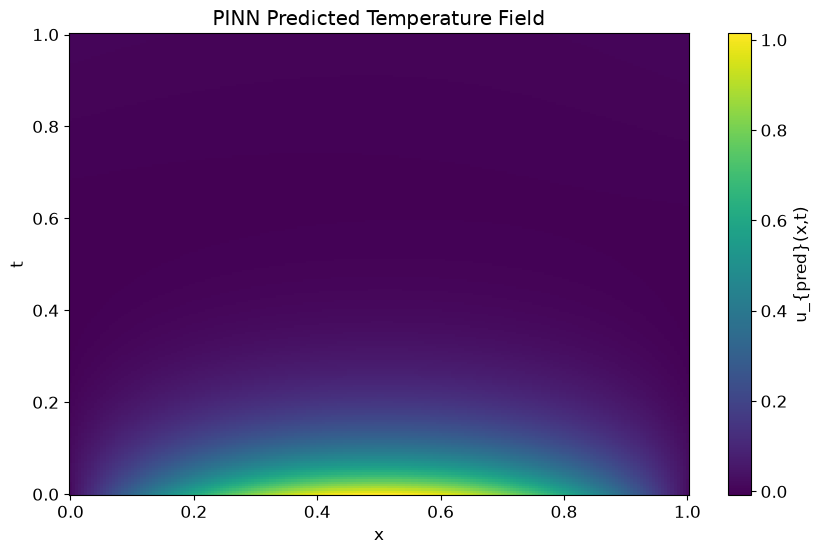

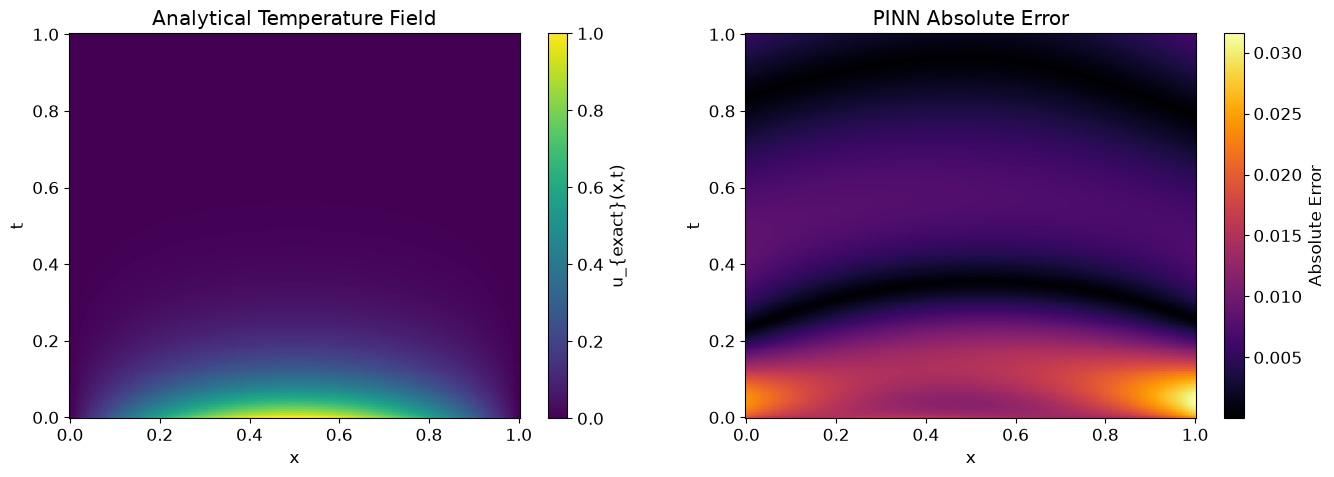

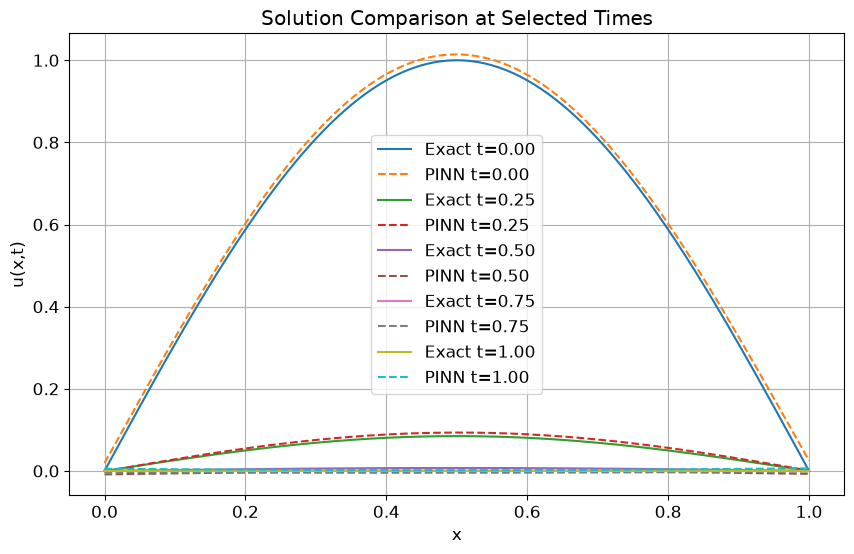

In [9]:
x_eval = torch.linspace(x_min, x_max, n_x, dtype=torch.float32).unsqueeze(-1)
t_eval = torch.linspace(t_min, t_max, n_t, dtype=torch.float32).unsqueeze(-1)
X, T = torch.meshgrid(x_eval.squeeze(-1), t_eval.squeeze(-1), indexing="xy")
X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

with torch.no_grad():
    u_pred_flat = model(X_flat, T_flat)

U_pred = u_pred_flat.reshape(n_t, n_x).cpu().numpy()
X_np = X.cpu().numpy()
T_np = T.cpu().numpy()
U_exact = np.exp(-alpha * np.pi**2 * T_np) * np.sin(np.pi * X_np)
abs_error = np.abs(U_pred - U_exact)
print(f"Max absolute error on evaluation grid: {abs_error.max():.4e}")
print(f"Mean absolute error on evaluation grid: {abs_error.mean():.4e}")

plt.figure()
plt.pcolormesh(X_np, T_np, U_pred, shading="auto", cmap="viridis")
plt.colorbar(label="u_{pred}(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Predicted Temperature Field")
plt.show()

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.pcolormesh(X_np, T_np, U_exact, shading="auto", cmap="viridis")
plt.colorbar(label="u_{exact}(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Analytical Temperature Field")

plt.subplot(1, 2, 2)
plt.pcolormesh(X_np, T_np, abs_error, shading="auto", cmap="inferno")
plt.colorbar(label="Absolute Error")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Absolute Error")
plt.show()

selected_times = [0.0, 0.25, 0.5, 0.75, 1.0]
plt.figure()
for t_val in selected_times:
    idx = np.abs(T_np[:, 0] - t_val).argmin()
    plt.plot(X_np[idx, :], U_exact[idx, :], label=f"Exact t={t_val:.2f}")
    plt.plot(X_np[idx, :], U_pred[idx, :], "--", label=f"PINN t={t_val:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Solution Comparison at Selected Times")
plt.legend()
plt.grid(True)
plt.show()